## Imports

In [21]:
import sys
import os
from pathlib import Path

from typing import Any, Annotated, List, Literal
from operator import add
import uuid
import json

from openai import OpenAI
from pydantic import BaseModel, Field, field_validator
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

# Add current directory to path to import tools package
from tools.tools import (
    # Shared
    get_current_date, calculate_date_window,
    check_machine_exists, list_available_machines,
    get_formatted_cm_context,
    get_intervention_detail,
    # Summarizer-specific
    summarize_intervention,
    build_known_case_template,
    save_known_case_template,
    get_known_case_templates,
    list_intervention_ids_by_date,
    # Troubleshooting-specific
    get_formatted_procedure_context,
    get_recent_formatted_cm_context,
    get_long_formatted_cm_context,
    get_sensor_catalog_tool, get_threshold_events_tool,
    get_sensor_timeline_tool, get_sensor_readings_tool,
    get_sensor_anomaly_summary,
    get_remaining_life_tool,
    query_known_issues_graph,
    get_fleet_impact_for_symptom,
    list_procedure_sections,
    list_known_issue_categories,
    find_similar_machines,
)

from utils.prompt_management import prompt_template_config


GENERATION_MODEL = "gpt-4o-mini"

## States

### Coordinator States

In [22]:
class Delegation(BaseModel):
    agent: str = Field(description="The agent to invoke")
    task: str = Field(description="The task to be performed by the agent")
    machine_id: str = None
    symptom: str = None
    period: str = None
    
class Plan(BaseModel):
    next_agent: str = Field(description="The next agent to invoke")
    plan: List[Delegation]

class FinalCoordinatorResponse(BaseModel):
    answer: str = Field(description="Answer to the question")

class CoordinatorAgentProperties(BaseModel):
    iteration: int = 0
    final_answer: bool = False
    plan: List[Delegation] = Field(default_factory=list)
    next_agent: str = ""

### SummarizerStates

In [23]:
class Reference(BaseModel):
    source_id: str

class TemplateReview(BaseModel):
    is_valid: bool = Field(description="Whether the template is valid and reliable")
    issues: List[str] = Field(default_factory=list, description="List of issues found")
    recommendations: List[str] = Field(default_factory=list, description="Recommendations for improvement")

class FinalSummarizerResponse(BaseModel):
    answer: str = Field(description="Final answer or follow-up question to the user.")

### TroubleshootingStates

In [24]:
from typing import Annotated
from operator import add


LIKELY_THRESHOLD = 0.85
REJECT_THRESHOLD = 0.05


class Hypothesis(BaseModel):
    hypothesis_id: str
    statement: str
    explanation: str = ""
    confidence: float
    status: Literal['ACTIVE', 'LIKELY', 'CONFIRMED', 'REJECTED'] = 'ACTIVE'
    sources: list[str] = Field(default_factory=list)


class SavedCase(BaseModel):
    case_id: str
    machine_id: str
    symptom: str
    root_cause: str
    actions: list[str] = Field(default_factory=list)


class FinalRCAResponse(BaseModel):
    """The user-facing reply and complete updated hypothesis ledger."""
    answer: str = Field(description="User-facing narrative summarizing findings and next steps.")
    hypotheses: list[Hypothesis] = Field(default_factory=list, description="Complete hypothesis ledger.")


class TroubleshootingAgentProperties(BaseModel):
    iteration: int = 0
    final_answer: bool = False
    hypotheses: list[Hypothesis] = Field(default_factory=list)
    machine_id: str = ""
    symptom: str = ""
    period: str = ""
    confirmed_root_cause: str = ""
    saved_case: SavedCase | None = None
    answer: str = ""

### MultiAgentState

In [25]:
class SummarizerAgentProperties(BaseModel):
    iteration: int = 0
    final_answer: bool = False
    template_content: str = ""
    template_review: TemplateReview | None = None


class MultiAgentState(BaseModel):
    messages: Annotated[List[Any], add] = Field(default_factory=list)
    answer: str = ""
    coordinator_agent: CoordinatorAgentProperties = Field(default_factory=CoordinatorAgentProperties)
    summarizer_agent: SummarizerAgentProperties = Field(default_factory=SummarizerAgentProperties)
    troubleshooting_agent: TroubleshootingAgentProperties = Field(default_factory=TroubleshootingAgentProperties)

## Tools (All)

In [26]:
_llm = ChatOpenAI(model=GENERATION_MODEL)
_coordinator_llm_with_tools = _llm.bind_tools([Plan, FinalCoordinatorResponse], tool_choice="any", parallel_tool_calls=False)
print("Coordinator LLM bound with: Plan, FinalCoordinatorResponse")


SUMARIZER_ALL_TOOLS = [
    get_current_date,
    calculate_date_window,
    check_machine_exists,
    list_available_machines,
    get_formatted_cm_context,
    get_intervention_detail,
    summarize_intervention,
    build_known_case_template,
    save_known_case_template,
    get_known_case_templates,
    list_intervention_ids_by_date,
]

print(f"Defined Summarizer {len(SUMARIZER_ALL_TOOLS)} tools: {[t.name for t in SUMARIZER_ALL_TOOLS]}")

_summarizer_llm_with_tools = ChatOpenAI(model=GENERATION_MODEL).bind_tools(
    SUMARIZER_ALL_TOOLS + [FinalSummarizerResponse], tool_choice="auto", parallel_tool_calls=True
)


# -- Troubleshooting: unified ReAct agent --

class SetInvestigation(BaseModel):
    """Anchor the investigation. Call once, as soon as you know both fields."""
    machine_id: str = Field(description="Machine identifier, e.g. 'HX-200'.")
    symptom: str = Field(description="Short symptom description, e.g. 'High oil temperature, >80C'.")
    period: str = Field(default="", description="Optional: onset date or relative time.")


class ConfirmRootCause(BaseModel):
    """Lock in one hypothesis as the confirmed root cause.

    Marks that hypothesis CONFIRMED and every other one REJECTED.
    Call only after the user has explicitly agreed.
    """
    hypothesis_id: str


class SaveCase(BaseModel):
    """Persist the closed case for future reference.

    Pre-conditions:
    - ConfirmRootCause must have been called this conversation.
    - The user must have explicitly approved saving.
    """
    machine_id: str = Field(description="Machine the case is about (e.g. 'HX-200').")
    symptom: str = Field(description="Original symptom.")
    root_cause: str = Field(description="The confirmed root cause statement.")
    actions: list[str] = Field(description="Recommended action plan, one item per step.")


class SummarizeInvestigation(BaseModel):
    """Mark that a recap is requested."""
    pass


RCA_LEDGER_SCHEMAS = [
    SetInvestigation,
    ConfirmRootCause,
    SaveCase,
    SummarizeInvestigation,
]
RCA_LEDGER_NAMES = {cls.__name__ for cls in RCA_LEDGER_SCHEMAS}
RCA_SCHEMA_NAMES = RCA_LEDGER_NAMES | {"FinalRCAResponse"}

RCA_ALL_TOOLS = [
    check_machine_exists, get_current_date, calculate_date_window,
    list_procedure_sections, list_known_issue_categories, find_similar_machines,
    get_formatted_procedure_context,
    get_recent_formatted_cm_context,
    get_long_formatted_cm_context,
    get_formatted_cm_context,
    get_sensor_catalog_tool, get_threshold_events_tool,
    get_sensor_timeline_tool, get_sensor_readings_tool,
    get_sensor_anomaly_summary,
    get_remaining_life_tool,
    query_known_issues_graph,
    get_intervention_detail,
    get_fleet_impact_for_symptom,
]

print(f"Defined RCA {len(RCA_ALL_TOOLS)} tools: {[t.name for t in RCA_ALL_TOOLS]}")

_rca_llm_with_tools = ChatOpenAI(model=GENERATION_MODEL).bind_tools(
    RCA_ALL_TOOLS + RCA_LEDGER_SCHEMAS + [FinalRCAResponse],
    tool_choice="auto",
)
_rca_llm_force_final = ChatOpenAI(model=GENERATION_MODEL).bind_tools(
    [FinalRCAResponse], tool_choice="FinalRCAResponse"
)

troubleshooting_tool_node = ToolNode(RCA_ALL_TOOLS)

Coordinator LLM bound with: Plan, FinalCoordinatorResponse
Defined Summarizer 11 tools: ['get_current_date', 'calculate_date_window', 'check_machine_exists', 'list_available_machines', 'get_formatted_cm_context', 'get_intervention_detail', 'summarize_intervention', 'build_known_case_template', 'save_known_case_template', 'get_known_case_templates', 'list_intervention_ids_by_date']
Defined RCA 19 tools: ['check_machine_exists', 'get_current_date', 'calculate_date_window', 'list_procedure_sections', 'list_known_issue_categories', 'find_similar_machines', 'get_formatted_procedure_context', 'get_recent_formatted_cm_context', 'get_long_formatted_cm_context', 'get_formatted_cm_context', 'get_sensor_catalog_tool', 'get_threshold_events_tool', 'get_sensor_timeline_tool', 'get_sensor_readings_tool', 'get_sensor_anomaly_summary', 'get_remaining_life_tool', 'query_known_issues_graph', 'get_intervention_detail', 'get_fleet_impact_for_symptom']


## Coordinator Nodes

In [27]:
def coordinator_agent_node(state: MultiAgentState) -> dict:

    prompt_template = """You are the **Coordinator Agent** of Hephaestus, an industrial maintenance assistant.

    You do NOT diagnose failures or summarize history yourself. Your job is to:
    1. Understand what the technician is asking for.
    2. Decide which specialist agent should handle it (or handle small-talk / clarifications yourself).
    3. Hand off the task with a clear, self-contained instruction.
    4. When the specialist returns control, review the conversation and decide whether more work is needed or the user can be answered directly.

    ---

    ## YOUR TEAM

    ### troubleshooting_agent
    Use when the technician is **investigating a live or recent failure on a specific machine** and wants help finding the root cause.
    Capabilities:
    - Runs a ReAct RCA loop (intake → scoping → deep history → action plan).
    - Pulls procedures, knowledge graph patterns, recent CM interventions, sensor catalog/threshold events.
    - Maintains an evidence ledger of hypotheses with confidence scores and explicit sources (PROC_REF, GRAPH, INT, USER).
    - Asks discriminating questions, handles procedure checkpoints, confirms a diagnosis and saves the case.
    Signals to route here:
    - A symptom + a machine ID ("HX-200 oil temperature is 85°C since this morning").
    - "Why is X happening?", "help me diagnose", "what could cause...", "it's failing".
    - Procedure feedback inside an active RCA ("I tried it, didn't work").

    ### summarizer_agent
    Use when the technician wants an **overview of past interventions, fleet patterns, or a known-case template** — no live diagnosis.
    Capabilities:
    - Pulls and synthesizes historical CM interventions (recent / long / filtered by query).
    - Aggregates fleet impact for a given symptom.
    - Produces structured summaries: list of incidents, root-cause distribution, recurring patterns, known-case templates.
    Signals to route here:
    - "Show me all X on machine Y last year".
    - "Find the high oil temperature problems on HX-200 between 2025-01-01 and 2025-02-01".
    - "Has this happened before?", "is this fleet-wide?", "give me a summary of...".
    - "Build a known-case template for bearing failures on CB-200".

    ### FinalCoordinatorResponse (handled by you, the Coordinator)
    Use when:
    - The query is unrelated to maintenance (weather, email drafting, general chit-chat).
    - The query is too vague to route — needs clarification first (missing machine ID, missing symptom, missing time range).
    - The user is replying to a clarification you just asked.

    ---

    ## DECISION RULES

    1. **Diagnosis vs. Summary** — the key split:
       - "What is wrong / why is it failing now?" → troubleshooting_agent
       - "What has happened / what do we know / give me an overview" → summarizer_agent
    2. **Combine sequential asks for the same agent into one task.** If the user says "check sensors, remaining life, and the procedure for overtemp on HX-200", that's a single troubleshooting_agent task — not three.
    3. **Don't route if the query needs clarification.** Ask the missing piece yourself (machine ID, symptom, time window). One question per turn.
    4. **Don't route off-topic queries.** Politely say it's outside scope and offer what you can help with.
    5. **After an agent returns:** read the latest messages. If the user's original ask is fully answered, respond directly. If a follow-up requires the same or another agent, route again with a refined task description.

    ---

    ## HANDOFF FORMAT

    When you route, the task description must be concrete, self-contained, including machine ID, symptom, time window, and any constraints from the conversation. Do NOT paste the raw user message; rewrite it as a task.
    [MANDATORY] When routing to troubleshooting_agent, also set:
        - machine_id: the validated machine identifier (e.g. "HX-200")
        - symptom: the symptom in the technician's own words
        - period: the onset date or time reference if mentioned (else omit)
    ---

    ## EXAMPLES

    Question: "Machine HX-200 has high oil temperature, above 80°C, started yesterday"
    next_agent: troubleshooting_agent
    task: "Run RCA on HX-200. Symptom: oil temperature above 80°C, onset yesterday. Investigate root cause and propose action plan."
    machine_id: "HX-200"
    symptom: "oil temperature above 80°C"
    period: "yesterday"

    Question: "The HX-200 hydraulic press is showing high oil temperature warnings. Check current sensor readings, remaining life of components, and the procedure for overtemperature faults."
    next_agent: troubleshooting_agent
    task: "Run RCA on HX-200 for high oil temperature warnings. Pull current sensor readings, component remaining life, and the overtemperature troubleshooting procedure as part of scoping."
    machine_id: "HX-200"
    symptom: "high oil temperature warnings"
    period: (omitted — no onset mentioned)

    Question: "I tried the cooling-system procedure and it didn't help"
    (Context: troubleshooting_agent is mid-investigation on HX-200, high oil temperature)
    next_agent: troubleshooting_agent
    task: "Technician reports the cooling-system procedure was attempted and did not resolve the issue. Update the ledger and pivot to deep history / fleet patterns."
    machine_id: "HX-200"
    symptom: "high oil temperature"
    period: (carry from conversation context)

    Question: "The HX-200 hydraulic press is showing high oil temperature warnings. Check current sensor readings, remaining life of components, and the procedure for overtemperature faults."
    next_agent: troubleshooting_agent
    task: "Run RCA on HX-200 for high oil temperature warnings. Pull current sensor readings, component remaining life, and the overtemperature troubleshooting procedure as part of scoping."

    Question: "Show me all bearing failures on CB-200 last year"
    next_agent: summarizer_agent
    task: "Summarize all bearing-failure interventions on CB-200 over the last 12 months. Include intervention list, root-cause breakdown, and any fleet-wide pattern."

    Question: "Has the cooler fouling issue happened on other machines too?"
    next_agent: summarizer_agent
    task: "Check fleet impact for the symptom 'cooler fouling'. List affected machines and recurrence pattern."

    Question: "Build me a known-case template for high oil temperature on hydraulic presses"
    next_agent: summarizer_agent
    task: "Produce a known-case template for 'high oil temperature' on hydraulic presses based on historical interventions: typical root causes, diagnostic steps, recommended actions."

    Question: "I tried the cooling-system procedure and it didn't help"
    (Context: troubleshooting_agent is mid-investigation)
    next_agent: troubleshooting_agent
    task: "Technician reports the cooling-system procedure was attempted and did not resolve the issue. Update the ledger and pivot to deep history / fleet patterns."

    Question: "What's the weather like today?"
    next_agent: FinalCoordinatorResponse
    answer: "I'm a maintenance assistant — I can help with diagnosing machine failures or summarizing past interventions, but not the weather."

    Question: "Can you help me?"
    next_agent: FinalCoordinatorResponse
    answer: "Of course. Are you trying to diagnose a current issue on a specific machine, or do you want a summary of past interventions? If it's a current issue, please share the machine ID and the symptom."

    Question: "It's overheating"
    next_agent: FinalCoordinatorResponse
    answer: "Which machine is overheating, and when did it start?"

    ---

    ## OUTPUT

    Decide one of: `troubleshooting_agent`, `summarizer_agent`, `FinalCoordinatorResponse`.
    - If routing: call the `Plan` tool with `next_agent` and a list of `Delegation` items (agent + task).
    - If handling yourself: call `FinalCoordinatorResponse` with the answer text.
    """

    response = _coordinator_llm_with_tools.invoke([
        SystemMessage(content=prompt_template),
        *state.messages
    ])

    final_answer = False
    answer = ""
    plan = []
    next_agent = ""
    messages = [response]
    troubleshooting_update = {}
    
    if response.tool_calls:
        call = response.tool_calls[0]
        if call.get("name") == "Plan":
            args = call.get("args", {})
            plan = args.get("plan", [])
            next_agent = args.get("next_agent", "")
            
            
            if next_agent == "troubleshooting_agent" and plan:
                first = plan[0]
                if first.get("machine_id"):
                    troubleshooting_update["machine_id"] = first["machine_id"]
                if first.get("symptom"):
                    troubleshooting_update["symptom"] = first["symptom"]
                if first.get("period"):
                    troubleshooting_update["period"] = first["period"]
            
            # OpenAI requires a ToolMessage for every tool_call_id in the history
            messages.append(ToolMessage(
                content=f"Routing to {next_agent}.",
                tool_call_id=call["id"],
            ))
        
        else:  # FinalCoordinatorResponse
            answer = call.get("args", {}).get("answer", "")
            final_answer = True
            messages.append(ToolMessage(
                content=answer,
                tool_call_id=call["id"],
            ))

    return_dict = {
        "messages": messages,
        "coordinator_agent": {
            "iteration": state.coordinator_agent.iteration + 1,
            "final_answer": final_answer,
            "plan": plan,
            "next_agent": next_agent,
        },
        "answer": answer,
    }

    # Only update troubleshooting_agent state when there are actual fields to set.
    # Use model_copy to preserve existing fields (hypotheses, confirmed_root_cause, etc.)
    # rather than returning a bare dict which would reset all unset fields to defaults.
    if troubleshooting_update:
        return_dict["troubleshooting_agent"] = state.troubleshooting_agent.model_copy(
            update=troubleshooting_update
        )

    return return_dict

In [28]:
def coordinator_agent_edge(state: MultiAgentState) -> str:
    if state.coordinator_agent.final_answer:
        return "end"
    elif state.coordinator_agent.next_agent == "summarizer_agent":
        return "summarizer_agent"
    elif state.coordinator_agent.next_agent == "troubleshooting_agent":
        return "troubleshooting_agent"
    else:
        return "end"

## Summarizer Nodes

In [29]:
def validate_template(template_content: str) -> TemplateReview:
    """Review known case template for reliability and structure."""
    issues = []
    recommendations = []

    required_sections = ["Symptom Name", "Root Causes", "Affected Machines"]
    for section in required_sections:
        if section not in template_content:
            issues.append(f"Missing required section: '{section}'")

    if "Root Causes:" in template_content:
        root_causes_section = template_content.split("Root Causes:")[1]
        root_cause_count = len([line for line in root_causes_section.split('\n') if line.strip() and line.strip()[0].isdigit()])
        if root_cause_count < 1:
            issues.append("At least one root cause must be documented")
        elif root_cause_count == 1:
            recommendations.append("Consider collecting more interventions to document multiple root causes for better coverage")

    if "Representative Intervention IDs:" not in template_content:
        issues.append("Missing representative intervention IDs for traceability")
    else:
        ids_section = template_content.split("Representative Intervention IDs:")[1]
        if not any(id_marker in ids_section for id_marker in ["INT-"]):
            issues.append("Representative intervention IDs section contains no valid INT- IDs")

    if "Affected Machines:" in template_content:
        machines_section = template_content.split("Affected Machines:")[1].split("\n")[0]
        if not machines_section.strip():
            issues.append("Affected Machines field is empty")

    if len(template_content) < 200:
        issues.append("Template content is too brief; ensure all sections are properly documented")

    if "**" not in template_content:
        recommendations.append("Consider using bold formatting for section headers for clarity")

    is_valid = len(issues) == 0
    return TemplateReview(is_valid=is_valid, issues=issues, recommendations=recommendations)


def summarizer_template_review_node(state: MultiAgentState) -> dict:
    """Review the generated template and persist if valid."""
    template_content = state.summarizer_agent.template_content
    if not template_content:
        return {}

    review = validate_template(template_content)

    if not review.is_valid:
        issues_text = "\n".join([f"- {issue}" for issue in review.issues])
        feedback_msg = f"""
The generated template has validation issues that need to be addressed before sending to the user:

{issues_text}

Please review the template and address these issues. You may need to:
1. Request more intervention summaries from the operator
2. Rebuild the template with more complete information
3. Fill in missing sections with data from the collected interventions

After fixing these issues, I'll validate the template again.
        """
        return {
            "messages": [ToolMessage(content=feedback_msg, tool_call_id="review", name="template_review")],
            "summarizer_agent": {
                "iteration": state.summarizer_agent.iteration,
                "final_answer": state.summarizer_agent.final_answer,
                "template_content": template_content,
                "template_review": review,
            },
        }

    try:
        symptom_name = extract_field(template_content, "Symptom Name:")
        description = extract_field(template_content, "Description:")
        affected_machines = extract_field(template_content, "Affected Machines:")
        affected_families = extract_field(template_content, "Affected Machine Families:")
        representative_ids = extract_field(template_content, "Representative Intervention IDs:")
        root_causes = parse_root_causes(template_content)

        save_result = save_known_case_template(
            symptom_name=symptom_name,
            description=description,
            root_causes_json=json.dumps(root_causes),
            affected_machines=affected_machines,
            affected_machine_families=affected_families,
            representative_intervention_ids=representative_ids,
            created_by_agent="summarizer_agent",
            validation_status="valid",
            validation_issues_json=json.dumps([])
        ).invoke({})

        final_answer = state.answer
        if save_result.get("status") == "success":
            template_id = save_result.get("template_id", "")
            final_answer += f"\n\n✓ **Template saved successfully!**\n"
            final_answer += f"- Template ID: `{template_id}`\n"
            final_answer += f"- Created by: {save_result.get('created_at', 'N/A')}\n"
            final_answer += f"- Machines: {', '.join(save_result.get('affected_machines', []))}\n"
            final_answer += f"- Coverage: {len(save_result.get('representative_intervention_ids', []))} interventions\n"

        if review.recommendations:
            recommendations_text = "\n".join([f"- {rec}" for rec in review.recommendations])
            final_answer += f"\n\n**Suggestions for improvement:**\n{recommendations_text}"

        return {
            "answer": final_answer,
            "summarizer_agent": {
                "iteration": state.summarizer_agent.iteration,
                "final_answer": True,
                "template_content": template_content,
                "template_review": review,
            },
        }

    except Exception as e:
        return {
            "answer": state.answer + f"\n\n⚠️ Error saving template: {str(e)}",
            "summarizer_agent": {
                "iteration": state.summarizer_agent.iteration,
                "final_answer": True,
                "template_content": template_content,
                "template_review": review,
            },
        }


def extract_field(content: str, field_marker: str) -> str:
    if field_marker not in content:
        return ""
    start = content.find(field_marker) + len(field_marker)
    next_section = content.find("\n**", start)
    end = next_section if next_section != -1 else len(content)
    return content[start:end].strip()


def parse_root_causes(content: str) -> list[dict]:
    root_causes = []
    if "Root Causes:" not in content:
        return root_causes
    section = content.split("Root Causes:")[1]
    if "Affected Machines:" in section:
        section = section.split("Affected Machines:")[0]
    import re
    pattern = r'^\d+\.\s+\*\*([^*]+)\*\*'
    for line in section.split('\n'):
        match = re.match(pattern, line)
        if match:
            root_causes.append({"root_cause": match.group(1), "actions": []})
    return root_causes

In [30]:
summarizer_tool_node = ToolNode(SUMARIZER_ALL_TOOLS)

In [31]:
def summarizer_agent_node(state: MultiAgentState) -> dict:
    SYSTEM_PROMPT = """
    You are a maintenance case analyst for past interventions. Help operators build known case templates by:
    1. Collecting machine, date range, and symptom
    2. Listing available interventions
    3. Waiting for operator to select which interventions to analyze
    4. Summarizing ONLY the selected interventions
    5. Building a template from those summaries

    ## Critical Workflow

    **STEP 1: List** — Get all INT-IDs for the machine/period
    - Use: list_intervention_ids_by_date()
    - Report count and list of INT-IDs by date order.
    - Wait for operator to provide a selection ONLY if count > 20. Otherwise, continue

    **STEP 2: Summarize** — Only after operator selects, summarize each INT
    - Use: summarize_intervention() for EACH selected INT-ID (can run in parallel)
    - Each summary is returned as "[INT: ID] summary text"
    - Collect ALL summaries and display them to operator with their [INT: ...] markers INTACT
    - Ask: "Anything else? I can also build a template of known cases for select IDs.

    **STEP 3: Build** — Only after operator confirms, build the template
    - Use: build_known_case_template() with ALL collected summaries joined together
    - Pass summaries EXACTLY AS RETURNED (with [INT: ...] markers) - do NOT reformat
    - Make sure you have included all IDs (directly and indirectly) informed by user
    - Present final template

    ## Summary Handling - IMPORTANT
    - When summarize_intervention() returns a summary, it includes "[INT: XXX-YYYY]" prefix
    - PRESERVE these markers - do not remove or reformat them
    - When showing summaries to operator, keep the [INT: ...] format visible
    - When passing to build_known_case_template(), concatenate all summaries as-is with newlines

    ## Required Information
    Collect once: machine_id, start_date, end_date, symptom (in a single request if missing).

    ## Confirmation Strategy
    - Do NOT reconfirm provided inputs.
    - Ask for selection: "Which INT-IDs to summarize?" (comma-separated or list)
    - Ask for confirmation: "Should I proceed to build the template from these summaries?" before calling build_known_case_template().
    - Never skip the summarize step or jump directly to build.

    ## Date Handling
    - Use get_current_date() and calculate_date_window() for relative dates.
    - Always work with ISO format (YYYY-MM-DD).
    """

    response = _summarizer_llm_with_tools.invoke(
        [SystemMessage(content=SYSTEM_PROMPT), *state.messages]
    )

    final_call = next(
        (tc for tc in response.tool_calls if tc["name"] == "FinalSummarizerResponse"),
        None
    )
    if final_call:
        parsed = FinalSummarizerResponse(**final_call["args"])
        return {
            "messages": [response],
            "answer": parsed.answer,
            "summarizer_agent": {
                "iteration": state.summarizer_agent.iteration + 1,
                "final_answer": True,
            },
        }

    if response.tool_calls:
        return {
            "messages": [response],
            "summarizer_agent": {
                "iteration": state.summarizer_agent.iteration + 1,
                "final_answer": False,
            },
        }

    return {
        "messages": [response],
        "answer": response.content,
        "summarizer_agent": {
            "iteration": state.summarizer_agent.iteration + 1,
            "final_answer": True,
        },
    }

In [32]:
def summarizer_route_after_agent(state: MultiAgentState) -> str:
    if state.summarizer_agent.iteration > 20:
        return END
    if state.summarizer_agent.final_answer:
        if state.summarizer_agent.template_content:
            return "summarizer_template_review"
        return END
    last_msg = state.messages[-1]
    if isinstance(last_msg, AIMessage) and getattr(last_msg, 'tool_calls', None):
        return "summarizer_tools"
    return END

## Troubleshooting Agent Node

In [33]:
RCA_SYSTEM_PROMPT = """You are an RCA Troubleshooting Copilot for industrial machines. You help a maintenance technician find the root cause of a symptom by first **orienting** in the operational landscape (what fault codes exist for this machine? what known-issue categories touch it? which peer machines have similar history?), then retrieving **targeted** evidence, proposing hypotheses **only when evidence supports them**, and refining with the user.

## Mental model: Discover -> Deep Dive

Behave like an investigator, not a chatbot over PDFs. Before retrieving chunks, understand the semantic landscape:
1. **Orient** -- which fault codes / known-issue categories exist for this machine and its peers?
2. **Narrow** -- pick the most relevant category/section and a focused query.
3. **Gather evidence** -- retrieve scoped procedure + graph + CM history.
4. **Hypothesize from evidence** -- propose hypotheses from procedure AND graph, merge when they describe the same cause.
5. **Refine with the user.**

## How you act each turn

**ANCHOR PHASE (turn A, only once per case):**
If you have machine_id and symptom in the Investigation state prompt but they're NOT yet anchored (no `SetInvestigation` call has been made yet):
- IMMEDIATELY call `SetInvestigation(machine_id="...", symptom="...", period="...")`
- Parallel call `check_machine_exists(machine="...")`
- If period is empty, also call `get_current_date()`
- Do NOT call `FinalRCAResponse` this turn
- Do NOT narrate intent
- Just call the tools silently and wait for results

**STANDARD PHASE (after anchor):**
Each turn you may call any combination of:
- **Real tools** (orient, retrieval, sensors, dates) to gather evidence.
- **Ledger schemas** (`ConfirmRootCause`, `SaveCase`, `SummarizeInvestigation`) for lifecycle events.
- **`FinalRCAResponse`** to write the user-facing reply AND emit the full updated ledger.

End every turn with `FinalRCAResponse` UNLESS you called real tools -- then wait for results and continue next turn (no `FinalRCAResponse` on a tool-call turn).

**MISSING INPUT PHASE (if machine_id or symptom not in state):**
Call `FinalRCAResponse` asking for what's missing. Do nothing else that turn.

**Golden rule: no narration between tool calls.** Never say "I'll now...", "Let me check...", "Next I'll pull...". Just call tools silently.

## CRITICAL: Emit the FULL hypothesis ledger every turn

**Every FinalRCAResponse.hypotheses MUST include:**
- ALL unchanged hypotheses from the previous turn (carry them forward)
- ALL new hypotheses discovered this turn
- ALL hypotheses with updated confidence (if evidence or user input changed them)

The node will automatically detect mutations and apply them. Your job: emit the COMPLETE ledger each turn.

Do NOT try to manage mutations yourself via UpdateHypothesis. Just give us:
1. The full updated ledger
2. Clear user-facing explanation
3. The sources in each hypothesis so mutations can be traced

## Investigation arc

### 1. Anchor + validate (turn A)
- `SetInvestigation(machine_id="HX-200", symptom="High oil temperature, >80C", period="2025-05-01")`
- `check_machine_exists(machine="HX-200")`
- If period is empty, also call `get_current_date()`.
- No `FinalRCAResponse` on this turn.

### 2. Orient (turn B)
Silent turn. No `FinalRCAResponse`. In parallel:
- `list_procedure_sections(machine="<id>")` -- see which fault codes exist.
- `list_known_issue_categories(machine="<id>")` -- see the failure-mode landscape.

### 3. Gather (turn C)
Silent turn. No `FinalRCAResponse`. Fire four retrieval calls in parallel:
- `get_formatted_procedure_context(query="<focused query>", file_name="<machine>_Troubleshooting_Procedures", contains_table=True, expand_window=True, top_k=5)`
- `query_known_issues_graph(query="<focused query>", machine="<id>")`
- `get_recent_formatted_cm_context(query="<focused query>", machine="<id>", date_end="<resolved_date>", days_span=7, top_k=5)`
- `get_recent_formatted_cm_context(query="<focused query>", machine="<id>", date_end="<resolved_date>", days_span=30, top_k=5)`

### 4. Hypothesize + speak (turn D)
Call `FinalRCAResponse` with:
- `answer`: your user-facing message summarizing findings and next steps.
- `hypotheses`: the COMPLETE ledger. You MUST extract every distinct root-cause candidate from ALL tool results and add it as a hypothesis:

  **From `get_formatted_procedure_context` results (MANDATORY):**
  Each cause or fault condition listed in the procedure MUST become its own hypothesis.
  - Find the `[SOURCE: PROC_REF:...]` tag in the procedure result and copy it verbatim as the source_id.
  - Confidence: 0.50-0.65 (procedure only).
  - Example: procedure says "Check cooler fan — blocked airflow causes overtemp" → hypothesis "High oil temperature due to blocked cooler airflow", source=["PROC_REF:HX-200_Troubleshooting_Procedures:chunk#3"].

  **From `query_known_issues_graph` results:**
  - Each distinct cause node becomes a hypothesis with the `[SOURCE: GRAPH:INT-...]` tag verbatim.
  - Confidence: 0.60-0.75 (graph only).

  **From CM context tools (`get_recent_formatted_cm_context`, etc.):**
  - Each recurring cause in past interventions becomes or bumps a hypothesis with the `[SOURCE: INT-...]` tag verbatim.

  **Merging rule:** If a procedure cause and a graph cause describe the SAME physical failure, merge them into ONE hypothesis — list BOTH source IDs, confidence 0.70-0.85.

  **Never skip procedure-sourced hypotheses.** The procedure result must always produce at least one hypothesis with a `PROC_REF` source_id, unless the result is empty.

### 5. Drill in when useful
- Widen to peers when recent is empty.
- Long history for chronic suspicion.
- Discover sensors before reading them.
- Expand graph hits with `get_intervention_detail`.

### 6. User feedback — CRITICAL: Emit updated ledger in FinalRCAResponse

When the user provides feedback (affirm/reject), emit the FULL ledger in FinalRCAResponse.
The node will detect the mutation and apply it automatically.

**Affirmation** (user says "yes", "probably", "confirmed", "likely", "that makes sense", "dark fouling", etc.):
- In your response, acknowledge the affirmation
- In `FinalRCAResponse.hypotheses`, increase the confidence of the matching hypothesis
- Include the FULL ledger with all hypotheses

**Rejection** (user says "no", "that didn't work", "checked and it's fine", "ruled out", etc.):
- In your response, acknowledge the rejection
- In `FinalRCAResponse.hypotheses`, decrease the confidence of the matching hypothesis
- Include the FULL ledger with all hypotheses

The node will:
1. Detect the confidence change
2. Add "USER" to the hypothesis sources
3. Recalculate status (REJECTED/ACTIVE/LIKELY)

### 7. Confirm -- only when user explicitly agrees
When one hypothesis dominates (LIKELY, conf >= 0.85), present it and ask the user to confirm.
Only after explicit user agreement to confirm (look for confirmation keywords like "confirmed", "yes", "correct"): call `ConfirmRootCause(hypothesis_id="H1")` then `FinalRCAResponse`.

### 8. Save -- only when user explicitly approves
After confirmation, offer an action plan and ask to save.
Only after explicit user approval: call `SaveCase(...)` then `FinalRCAResponse`.

## Hard rules

- `FinalRCAResponse.hypotheses` MUST contain the full ledger every turn -- never a partial list.
- Always carry forward unchanged hypotheses from the previous turn.
- When confidence changes (user feedback or new evidence), emit the hypothesis with updated confidence in FinalRCAResponse.
- The node detects confidence changes and adds "USER" to sources automatically.
- Each source_id must come verbatim from a `[SOURCE: ...]` tag in a tool result.
- Procedure tool results MUST produce at least one hypothesis with a `PROC_REF` source_id (unless the result is empty).
- Two hypotheses must never describe the same physical cause.
- When calling `ConfirmRootCause` or `SaveCase`, you must detect confirmation/agreement keywords in the most recent user message.
- `get_recent_formatted_cm_context` ALWAYS requires `date_end`.

## Confidence guidelines
| Evidence | Confidence |
|---|---|
| Procedure only | 0.50-0.65 |
| Graph only | 0.60-0.75 |
| Procedure + Graph | 0.70-0.85 |
| Procedure + Graph + CM | 0.80-0.90 |
| User confirms | +0.20-0.30 |
| User rules out | -0.50-0.70 |

## Source ID conventions
- `PROC_REF:<file>:chunk#<n>` -- procedure documents
- `GRAPH:INT-...` -- known issue graph
- `INT-...` -- from CM context tools
- `USER` -- user statements
"""


# -- Helpers --

def _check_for_user_explicitly_agreement(messages: list) -> bool:
    """Check if the most recent user message contains explicit confirmation/agreement."""
    for msg in reversed(messages):
        if isinstance(msg, HumanMessage):
            text = (msg.content or "").strip().lower()
            affirmation_patterns = [
                "yes", "yep", "yeah", "confirmed", "confirm", "correct", 
                "agreed", "agree", "ok", "okay", "sure", "right", "absolutely",
                "definitely", "precisely", "exactly", "indeed"
            ]
            for pattern in affirmation_patterns:
                if pattern in text:
                    return True
            return False
    return False


def _check_for_user_affirmation(text: str) -> bool:
    """Detect user affirmation: yes, probably, likely, that makes sense, confirmed, etc."""
    text = text.strip().lower()
    affirmation_keywords = (
        "yes", "yep", "yeah", "probably", "likely", "makes sense", "confirmed", 
        "correct", "agreed", "ok", "okay", "sure", "right", "dark fouling", 
        "fouling", "blocked", "dirty", "clogged", "broken", "failed", "not working"
    )
    return any(kw in text for kw in affirmation_keywords)


def _check_for_user_rejection(text: str) -> bool:
    """Detect user rejection: no, didn't work, ruled out, checked and fine, etc."""
    text = text.strip().lower()
    rejection_keywords = (
        "no", "nope", "didn't work", "doesn't work", "didn't help", "doesn't help",
        "ruled out", "checked", "is fine", "normal", "ok", "good", "working", "fine"
    )
    return any(kw in text for kw in rejection_keywords)


def _rca_refresh_hypothesis_status(h: Hypothesis) -> None:
    if h.status == "CONFIRMED":
        return
    if h.confidence <= REJECT_THRESHOLD:
        h.status = "REJECTED"
    elif h.confidence >= LIKELY_THRESHOLD:
        h.status = "LIKELY"
    else:
        h.status = "ACTIVE"


def _rca_render_ledger(hypotheses: list[Hypothesis]) -> str:
    if not hypotheses:
        return "(no hypotheses yet)"
    sorted_h = sorted(hypotheses, key=lambda h: h.confidence, reverse=True)
    return "\n".join(
        f"- **{h.hypothesis_id}** [{h.status} conf={h.confidence:.2f}] {h.statement} -- sources: {', '.join(h.sources) or '?'}"
        for h in sorted_h
    )


def _rca_clamp(x: float) -> float:
    return max(0.0, min(1.0, x))


def _rca_ledger_status(ta: TroubleshootingAgentProperties) -> str:
    if ta.saved_case:
        return f"case saved as {ta.saved_case.case_id}"
    if ta.confirmed_root_cause:
        return f"root cause confirmed: {ta.confirmed_root_cause} (waiting for user to approve action plan / save)"
    return "investigating"


# -- Mutation engine: Automatic hypothesis diffing --

def _rca_detect_user_feedback(messages: list) -> tuple[str, str]:
    """Scan recent user message for affirmation/rejection + extract the feedback text.
    Returns: (feedback_type: "affirm"|"reject"|"none", feedback_text: str)
    """
    for msg in reversed(messages):
        if isinstance(msg, HumanMessage):
            text = (msg.content or "").strip().lower()
            if _check_for_user_affirmation(text):
                return ("affirm", msg.content.strip())
            elif _check_for_user_rejection(text):
                return ("reject", msg.content.strip())
            return ("none", "")
    return ("none", "")


def _rca_find_matching_hypothesis(
    hypotheses: list[Hypothesis], feedback_text: str
) -> Hypothesis | None:
    """Find the most likely hypothesis that matches the user's feedback context.
    Simple heuristic: find hypothesis with highest confidence (the one the user is responding to).
    """
    if not hypotheses:
        return None
    return max(hypotheses, key=lambda h: h.confidence)


def _rca_apply_hypothesis_diffs(
    old_hypotheses: list[Hypothesis],
    new_hypotheses: list[Hypothesis],
    messages: list
) -> list[Hypothesis]:
    """
    Auto-detect and apply mutations when hypotheses change between turns.
    
    Logic:
    1. If user provided feedback (affirm/reject), find the matching hypothesis and adjust confidence
    2. If a hypothesis exists in old but not new → carry it forward (unchanged)
    3. If a hypothesis exists in new with higher confidence → add USER to sources
    4. Refresh all statuses based on new confidences
    """
    old_map = {h.hypothesis_id: h for h in old_hypotheses}
    new_map = {h.hypothesis_id: h.model_copy() for h in new_hypotheses}
    
    # Detect user feedback
    feedback_type, feedback_text = _rca_detect_user_feedback(messages)
    
    if feedback_type in ("affirm", "reject"):
        # Find the hypothesis the user is responding to (highest confidence in old ledger)
        if old_hypotheses:
            matching_h = _rca_find_matching_hypothesis(old_hypotheses, feedback_text)
            if matching_h and matching_h.hypothesis_id in new_map:
                new_h = new_map[matching_h.hypothesis_id]
                
                # Apply mutation based on feedback type
                if feedback_type == "affirm":
                    new_h.confidence = _rca_clamp(new_h.confidence + 0.25)
                elif feedback_type == "reject":
                    new_h.confidence = _rca_clamp(new_h.confidence - 0.60)
                
                # Add USER source if not already present
                if "USER" not in new_h.sources:
                    new_h.sources.append("USER")
                
                _rca_refresh_hypothesis_status(new_h)
    
    # Carry forward hypotheses that exist in old but not in new
    for h_id, old_h in old_map.items():
        if h_id not in new_map:
            new_map[h_id] = old_h.model_copy()
    
    # Refresh all statuses
    for h in new_map.values():
        _rca_refresh_hypothesis_status(h)
    
    return list(new_map.values())


def _rca_apply_mutations(
    state: MultiAgentState, response, final_hypotheses: list[Hypothesis]
) -> tuple[list[Hypothesis], str, str, str, str, "SavedCase | None", list[str]]:
    """Apply ledger-schema tool calls (SetInvestigation, ConfirmRootCause, SaveCase).
    Hypotheses are auto-diffed and mutations applied at the node level.
    Returns (hypotheses, machine_id, symptom, period, confirmed, saved, notes).
    """
    ta = state.troubleshooting_agent
    old_hypotheses = list(ta.hypotheses)
    machine_id = ta.machine_id
    symptom = ta.symptom
    period = ta.period
    confirmed = ta.confirmed_root_cause
    saved = None
    notes: list[str] = []

    # Step 1: Apply SetInvestigation
    for tc in getattr(response, "tool_calls", []) or []:
        name, args = tc["name"], tc.get("args") or {}

        if name == "SetInvestigation":
            if args.get("machine_id"):
                machine_id = args["machine_id"]
            if args.get("symptom"):
                symptom = args["symptom"]
            if args.get("period"):
                period = args["period"]

    # Step 2: Auto-diff hypotheses and apply mutations based on user feedback
    hypotheses = _rca_apply_hypothesis_diffs(old_hypotheses, final_hypotheses, state.messages)

    # Step 3: Apply ConfirmRootCause and SaveCase
    for tc in getattr(response, "tool_calls", []) or []:
        name, args = tc["name"], tc.get("args") or {}

        if name == "ConfirmRootCause":
            if not _check_for_user_explicitly_agreement(state.messages):
                notes.append("Refused ConfirmRootCause: user did not explicitly agree.")
                continue
            target = args.get("hypothesis_id")
            for h in hypotheses:
                if h.hypothesis_id == target:
                    h.status = "CONFIRMED"
                    h.confidence = 1.0
                    confirmed = h.statement
                elif h.status != "REJECTED":
                    h.status = "REJECTED"

        elif name == "SaveCase":
            if not confirmed:
                notes.append("Refused SaveCase: no confirmed root cause yet.")
                continue
            if not _check_for_user_explicitly_agreement(state.messages):
                notes.append("Refused SaveCase: user did not explicitly approve saving.")
                continue
            saved = SavedCase(
                case_id=f"CASE-{__import__('uuid').uuid4().hex[:8].upper()}",
                machine_id=args.get("machine_id", machine_id),
                symptom=args.get("symptom", symptom),
                root_cause=args.get("root_cause", confirmed),
                actions=args.get("actions", []) or [],
            )

    return hypotheses, machine_id, symptom, period, confirmed, saved, notes


def _rca_classify_response(response) -> tuple:
    """Split tool_calls into (sanitized_message, executable_real_tools, final_rca_call)."""
    tool_calls = list(getattr(response, "tool_calls", []) or [])
    final_rca_call = None
    executable = []
    for tc in tool_calls:
        if tc["name"] == "FinalRCAResponse":
            final_rca_call = tc
        elif tc["name"] not in RCA_SCHEMA_NAMES:
            executable.append(tc)

    sanitized = AIMessage(
        content=getattr(response, "content", "") or "",
        tool_calls=executable,
        id=getattr(response, "id", None),
    )
    return sanitized, executable, final_rca_call


def _rca_build_system(state: MultiAgentState, notes: list[str]) -> SystemMessage:
    ta = state.troubleshooting_agent
    notes_block = "\n".join(f"- {n}" for n in notes) if notes else "(none)"
    status = _rca_ledger_status(ta)
    period_str = (
        f"Period: {ta.period}" if ta.period
        else "Period: (not set -- call SetInvestigation with optional period, or get_current_date() will be used)"
    )

    current_task = state.coordinator_agent.plan[0].task if state.coordinator_agent.plan else "(none)"

    return SystemMessage(content=(
        RCA_SYSTEM_PROMPT
        + "\n\n## Investigation state\n"
        + f"Status: {status}\n"
        + f"Machine: {ta.machine_id or '(not set)'}\n"
        + f"Symptom: {ta.symptom or '(not set)'}\n"
        + period_str + "\n"
        + f"Iteration: {ta.iteration}\n\n"
        + "### Ledger\n"
        + _rca_render_ledger(ta.hypotheses)
        + "\n\n### System notes from last turn\n"
        + notes_block
        + "\n\n### Current Task from Coordinator\n"
        + current_task
    ))


_RCA_NOTES_STASH: dict[str, list[str]] = {}

RCA_MAX_ITERATIONS = 20


def _rca_force_final_response(state: MultiAgentState) -> tuple[str, list[Hypothesis]]:
    """Last-resort: force FinalRCAResponse when the main pass forgot it."""
    response = _rca_llm_force_final.invoke([_rca_build_system(state, [])] + state.messages + [
        SystemMessage(content="Write the user-facing reply now via FinalRCAResponse, including the full updated hypothesis ledger.")
    ])
    for tc in getattr(response, "tool_calls", []) or []:
        if tc["name"] == "FinalRCAResponse":
            parsed = FinalRCAResponse(**tc["args"])
            return parsed.answer.strip(), parsed.hypotheses
    return "", list(state.troubleshooting_agent.hypotheses)


def troubleshooting_agent_node(state: MultiAgentState, config) -> dict:
    """Unified ReAct RCA agent -- hypotheses auto-diffed and mutated at the node level."""
    ta = state.troubleshooting_agent
    thread_id = config["configurable"]["thread_id"]
    notes_in = _RCA_NOTES_STASH.pop(thread_id, [])

    response = _rca_llm_with_tools.invoke([_rca_build_system(state, notes_in)] + state.messages)
    sanitized, executable, final_rca_call = _rca_classify_response(response)

    if executable:
        # Real tools pending — ToolNode runs them, reply comes next turn.
        # Apply only SetInvestigation from this turn (no final ledger yet).
        _, machine_id, symptom, period, confirmed, new_saved, notes = _rca_apply_mutations(
            state, response, list(ta.hypotheses)
        )
        if notes:
            _RCA_NOTES_STASH[thread_id] = notes
        return {
            "messages": [sanitized],
            "troubleshooting_agent": ta.model_copy(update={
                "iteration": ta.iteration + 1,
                "final_answer": False,
                "machine_id": machine_id,
                "symptom": symptom,
                "period": period,
                "confirmed_root_cause": confirmed,
                "saved_case": new_saved or ta.saved_case,
            }),
        }

    # Extract hypotheses from FinalRCAResponse
    if final_rca_call:
        parsed = FinalRCAResponse(**final_rca_call["args"])
        raw_hypotheses = parsed.hypotheses
        final_answer_text = parsed.answer.strip()
    else:
        # Fallback: no FinalRCAResponse was called
        final_answer_text, raw_hypotheses = _rca_force_final_response(state)

    new_hypotheses, machine_id, symptom, period, confirmed, new_saved, notes = _rca_apply_mutations(
        state, response, raw_hypotheses
    )
    if notes:
        _RCA_NOTES_STASH[thread_id] = notes

    if not final_answer_text:
        final_answer_text = "I'm still working on this -- could you give me a moment, or rephrase what you'd like next?"

    spoken = AIMessage(content=final_answer_text, id=getattr(response, "id", None))
    msgs_out = [spoken] if not sanitized.content else [sanitized, spoken]

    return {
        "messages": msgs_out,
        "answer": final_answer_text,
        "troubleshooting_agent": ta.model_copy(update={
            "iteration": ta.iteration + 1,
            "final_answer": True,
            "hypotheses": new_hypotheses,
            "machine_id": machine_id,
            "symptom": symptom,
            "period": period,
            "confirmed_root_cause": confirmed,
            "saved_case": new_saved or ta.saved_case,
            "answer": final_answer_text,
        }),
    }


def troubleshooting_route_after_agent(state: MultiAgentState) -> str:
    ta = state.troubleshooting_agent
    if ta.final_answer or ta.iteration >= RCA_MAX_ITERATIONS:
        return END
    last = state.messages[-1] if state.messages else None
    tool_calls = getattr(last, "tool_calls", None) or []
    return "troubleshooting_tools" if tool_calls else END

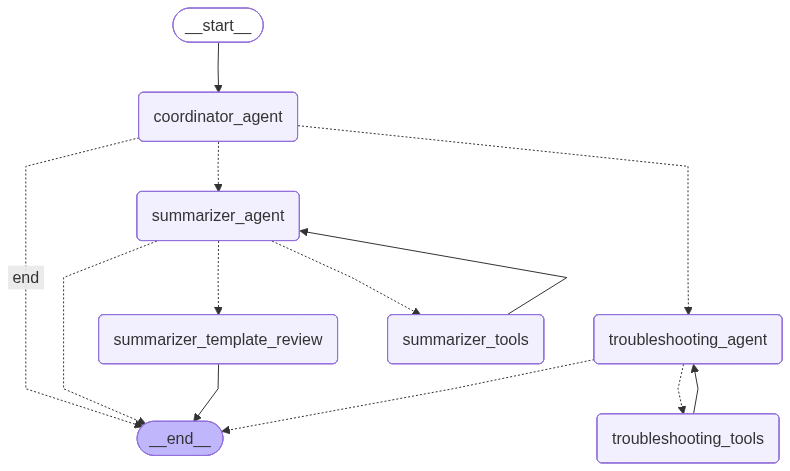

In [34]:
workflow = StateGraph(MultiAgentState)

# Nodes
workflow.add_node("coordinator_agent", coordinator_agent_node)
workflow.add_node("summarizer_agent", summarizer_agent_node)
workflow.add_node("summarizer_tools", summarizer_tool_node)
workflow.add_node("summarizer_template_review", summarizer_template_review_node)
workflow.add_node("troubleshooting_agent", troubleshooting_agent_node)
workflow.add_node("troubleshooting_tools", troubleshooting_tool_node)

# Coordinator
workflow.add_edge(START, "coordinator_agent")
workflow.add_conditional_edges("coordinator_agent", coordinator_agent_edge, {
    "summarizer_agent": "summarizer_agent",
    "troubleshooting_agent": "troubleshooting_agent",
    "end": END,
})

# Summarizer sub-loop
workflow.add_conditional_edges("summarizer_agent", summarizer_route_after_agent, {
    "summarizer_tools": "summarizer_tools",
    "summarizer_template_review": "summarizer_template_review",
    END: END,
})
workflow.add_edge("summarizer_tools", "summarizer_agent")
workflow.add_edge("summarizer_template_review", END)

# Troubleshooting sub-loop (thinker+speaker, no separate confirm/closure nodes)
workflow.add_conditional_edges("troubleshooting_agent", troubleshooting_route_after_agent, {
    "troubleshooting_tools": "troubleshooting_tools",
    END: END,
})
workflow.add_edge("troubleshooting_tools", "troubleshooting_agent")

graph = workflow.compile(checkpointer=MemorySaver())

from utils.utils import display_graph
display_graph(graph)

## Tests

In [15]:
# --- Test 1: Out-of-scope — coordinator answers directly, no sub-agent invoked ---
result = graph.invoke(
    {"messages": [HumanMessage(content="What's the weather like today?")]},
    config={"configurable": {"thread_id": f"test-out-of-scope-{uuid.uuid4().hex[:8]}"}},
)

print("=== Test 1: Out-of-scope ===")
print(f"Answer: {result['answer']}")
print(f"Coordinator final_answer: {result['coordinator_agent']['final_answer']}")
print(f"Summarizer invoked: {result.get('summarizer_agent', {}).get('iteration', 0) > 0}")
print(f"Troubleshooting invoked: {result.get('troubleshooting_agent', {}).get('iteration', 0) > 0}")

=== Test 1: Out-of-scope ===
Answer: I'm a maintenance assistant — I can help with diagnosing machine failures or summarizing past interventions, but not the weather.
Coordinator final_answer: True
Summarizer invoked: False
Troubleshooting invoked: False


In [16]:
# --- Test 2: Summary path — coordinator routes to summarizer_agent ---
result = graph.invoke(
    {"messages": [HumanMessage(content="Find all high oil temperature interventions on HX-200 between 2025-01-01 and 2025-06-01.")]},
    config={"configurable": {"thread_id": f"test-summary-{uuid.uuid4().hex[:8]}"}},
)

print("=== Test 2: Summary path ===")
print(f"Answer: {result['answer']}")
print(f"Summarizer iterations: {result.get('summarizer_agent', {}).get('iteration', 0)}")
print(f"Summarizer final_answer: {result.get('summarizer_agent', {}).get('final_answer', False)}")
print(f"Troubleshooting invoked: {result.get('troubleshooting_agent', {}).get('iteration', 0) > 0}")

KeyboardInterrupt: 

In [ ]:
# --- Test 3: Diagnosis path — coordinator routes to troubleshooting_agent ---
thread_id = f"test-diagnosis-{uuid.uuid4().hex[:8]}"
config = {"configurable": {"thread_id": thread_id}}

result = graph.invoke(
    {"messages": [HumanMessage(content="Machine HX-200 has high oil temperature, above 80°C, started yesterday.")]},
    config=config,
)

print("=== Test 3: Diagnosis path (turn 1) ===")
print(f"Answer: {result['answer']}")
ta = result.get('troubleshooting_agent', {})
print(f"Troubleshooting iterations: {ta.get('iteration', 0) if isinstance(ta, dict) else ta.iteration}")
hypotheses = ta.get('hypotheses', []) if isinstance(ta, dict) else ta.hypotheses
print(f"Hypotheses found: {len(hypotheses)}")
for h in sorted(hypotheses, key=lambda x: (x.get('confidence', 0) if isinstance(x, dict) else x.confidence), reverse=True):
    if isinstance(h, dict):
        print(f"  {h['hypothesis_id']} [{h['status']} {h['confidence']:.2f}] {h['statement']}")
    else:
        print(f"  {h.hypothesis_id} [{h.status} {h.confidence:.2f}] {h.statement}")

=== Test 3: Diagnosis path (turn 1) ===
Answer: I found the relevant procedure for this. In section 3.2 of the HX-200 Troubleshooting Procedures, it describes the trigger condition for high oil temperature, where the TS-101 reading exceeds 65°C. Here are some diagnostic steps to follow:
1. Read the TS-101 temperature on the HMI and note the trend. If it's rising rapidly (more than 2°C a minute), consider reducing the cycle rate immediately.
2. Check the operation of the cooler fan HE-501. Make sure it's running and that the airflow is unobstructed.
3. Inspect the cooler fins for contamination and clean if necessary.
4. Lastly, check the ambient temperature in the shop; it should be below 40°C to ensure efficient cooling. 

Given that the oil temperature has been noted above 80°C, it's essential we act promptly. Do you have any other observations or results from these checks?
Troubleshooting iterations: 4
Hypotheses found: 3
  H1 [ACTIVE 0.70] High oil temperature due to cooler fouling 

In [ ]:
# --- Test 3 (turn 2): user confirms diagnosis → thinker calls ConfirmRootCause ---
result = graph.invoke(
    {"messages": [HumanMessage(content="yes, that's the root cause")]},
    config=config,
)

print("=== Test 3: Diagnosis path (turn 2 — confirm) ===")
print(f"Answer: {result['answer']}")
ta = result.get('troubleshooting_agent', {})
confirmed = ta.get('confirmed_root_cause', '') if isinstance(ta, dict) else ta.confirmed_root_cause
saved = ta.get('saved_case') if isinstance(ta, dict) else ta.saved_case
print(f"Confirmed root cause: {confirmed}")
print(f"Saved case: {saved}")
print(f"Summarizer invoked: {result.get('summarizer_agent', {}).get('iteration', 0) > 0}")

Deserializing unregistered type __main__.TroubleshootingAgentProperties from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'TroubleshootingAgentProperties')]


=== Test 3: Diagnosis path (turn 2 — confirm) ===
Answer: Great, I acknowledge the confirmation of cooler fouling as the root cause. Now, I'll draft an action plan to resolve the high oil temperature issue. Here’s a proposed plan:

1. **Inspect the cooler fins:** Examine for any blockage or contamination.
2. **Clean the cooler:** Use compressed air or pressure washing to remove debris from the cooler fins. 
3. **Check the operation of the cooler fan:** Ensure the fan is functioning properly and replace it if needed.
4. **Take oil sample:** Collect an oil sample after cleaning and send it for analysis to verify oil quality.
5. **Monitor oil temperature:** After repairs, watch the temperature closely for the next few hours to ensure it stabilizes below the critical threshold.
6. **Perform a system test:** Once everything is cleaned and checked, run a functional test to ensure normal operation.

Want me to save this case for future reference?
Confirmed root cause: 
Saved case: None
Summar

In [ ]:
# --- Test 4: Delegation handoff — verify machine_id, symptom, period are passed to troubleshooting_agent ---
# This test validates that after the coordinator routes to troubleshooting_agent,
# the sub-agent's state already has machine_id and symptom pre-populated from the
# coordinator's structured Delegation, so it never enters the MISSING INPUT phase.

result = graph.invoke(
    {"messages": [HumanMessage(content="CB-200 has been vibrating abnormally since yesterday morning.")]},
    config={"configurable": {"thread_id": f"test-delegation-{uuid.uuid4().hex[:8]}"}},
)

print("=== Test 4: Delegation handoff ===")

# 1. Coordinator routed to troubleshooting (not handled itself)
ca = result.get('coordinator_agent', {})
coordinator_final = ca.get('final_answer', True) if isinstance(ca, dict) else ca.final_answer
coordinator_next = ca.get('next_agent', '') if isinstance(ca, dict) else ca.next_agent
print(f"Coordinator routed to: {coordinator_next}")
assert coordinator_next == "troubleshooting_agent", f"Expected routing to troubleshooting_agent, got '{coordinator_next}'"
assert not coordinator_final, "Coordinator should NOT have answered directly"

# 2. Troubleshooting agent was actually invoked
ta = result.get('troubleshooting_agent', {})
ta_iter = ta.get('iteration', 0) if isinstance(ta, dict) else ta.iteration
assert ta_iter > 0, "Troubleshooting agent was never invoked"

# 3. machine_id and symptom were pre-populated before the first agent turn
ta_machine = ta.get('machine_id', '') if isinstance(ta, dict) else ta.machine_id
ta_symptom = ta.get('symptom', '') if isinstance(ta, dict) else ta.symptom
ta_period  = ta.get('period', '') if isinstance(ta, dict) else ta.period
print(f"machine_id  : {ta_machine!r}")
print(f"symptom     : {ta_symptom!r}")
print(f"period      : {ta_period!r}")
assert ta_machine, "machine_id was not pre-populated by the coordinator handoff"
assert ta_symptom, "symptom was not pre-populated by the coordinator handoff"
assert "CB-200" in ta_machine, f"Expected 'CB-200' in machine_id, got {ta_machine!r}"
assert "vibrat" in ta_symptom.lower(), f"Expected vibration symptom, got {ta_symptom!r}"

# 4. Sanity: summarizer was NOT invoked
sa_iter = result.get('summarizer_agent', {}).get('iteration', 0)
assert sa_iter == 0, "Summarizer should not have been invoked for a diagnosis request"

print("\nAll assertions passed. Coordinator correctly pre-populated troubleshooting state.")


=== Test 4: Delegation handoff ===
Coordinator routed to: troubleshooting_agent
machine_id  : 'CB-200'
symptom     : 'abnormal vibrations'
period      : '2025-05-10'

All assertions passed. Coordinator correctly pre-populated troubleshooting state.


## Interactive session


=== Hephaestus Coordinator — multi-agent (type 'exit' to quit) ===
Tips:
  Diagnosis : 'HX-200 has high oil temperature, >80C, started today'
  Summary   : 'Find all bearing failures on CB-200 last year'
  Off-topic : 'What is the weather today?'


Agent: After investigating the high oil temperature issue on the HX-200 hydraulic press, the following potential root causes have been identified based on recent interventions and troubleshooting procedures:

1. **Cooler Fouling**: Recent interventions indicated that fouling in the oil cooler is a recurring issue leading to high oil temperatures. It is important to check and clean the cooler fins regularly. This was noted in interventions on 2025-04-20 where diagnostic checks linked high oil temperatures to cooler fouling.

2. **Fan Failure**: Another notable cause involves the fan motor (HE-501-FAN), which has failed in several past incidents, causing high oil temperatures. This was particularly highlighted in an intervention on 2025-04-24

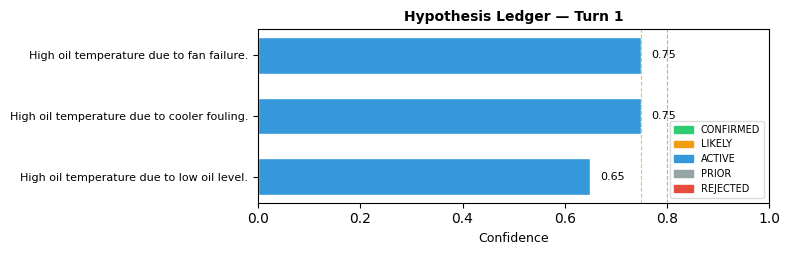

Deserializing unregistered type __main__.TroubleshootingAgentProperties from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'TroubleshootingAgentProperties')]



Agent: ### Findings Summary for HX-200 High Oil Temperature Due to Dark Fouling on Cooler

#### Recent Context & Alerts
- **Symptom**: High oil temperature linked to dark fouling on the cooler observed today.
- **Known Issues**: Cooler fouling has been identified as a critical factor leading to increased oil temperature in prior incidents on HX-200.

#### Root Causes Identified
Based on your input about the cooler condition and historical data, the following hypotheses have been established:

1. **High oil temperature due to fouled cooler fins** (dark fouling indicating blockage)
   - Confidence: 0.75  
   - Sources: [PROC_REF:HX-200_Troubleshooting_Procedures:chunk#10], [INT-2025-0062]

2. **High oil temperature due to fan failure** (potential impact of impaired airflow)
   - Confidence: 0.70  
   - Sources: [PROC_REF:HX-200_Troubleshooting_Procedures:chunk#9], [INT-2025-0366]

3. **High oil temperature due to low oil level** (secondary factor contributing to temperature rise)
   - C

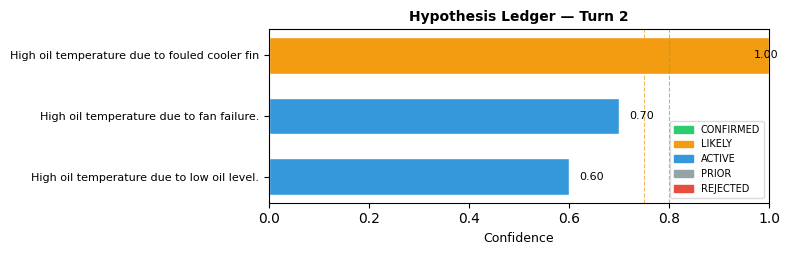

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


STATUS_COLORS = {
    "CONFIRMED": "#2ecc71",
    "LIKELY":    "#f39c12",
    "ACTIVE":    "#3498db",
    "PRIOR":     "#95a5a6",
    "REJECTED":  "#e74c3c",
}


def plot_hypothesis_ledger(hypotheses, turn_label=""):
    if not hypotheses:
        return

    def _get(h, key, default=""):
        return h.get(key, default) if isinstance(h, dict) else getattr(h, key, default)

    sorted_h = sorted(hypotheses, key=lambda h: _get(h, "confidence", 0))
    labels = [_get(h, "statement", "?")[:45] for h in sorted_h]
    confs  = [_get(h, "confidence", 0) for h in sorted_h]
    statuses = [_get(h, "status", "ACTIVE") for h in sorted_h]
    colors = [STATUS_COLORS.get(s, "#95a5a6") for s in statuses]

    fig, ax = plt.subplots(figsize=(8, max(2, 0.55 * len(sorted_h) + 1)))
    bars = ax.barh(labels, confs, color=colors, edgecolor="white", height=0.6)

    ax.set_xlim(0, 1.0)
    ax.axvline(0.75, color="#f39c12", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.axvline(0.80, color="#2ecc71", linestyle="--", linewidth=0.8, alpha=0.7)

    for bar, conf in zip(bars, confs):
        ax.text(min(conf + 0.02, 0.97), bar.get_y() + bar.get_height() / 2,
                f"{conf:.2f}", va="center", fontsize=8)

    legend_patches = [mpatches.Patch(color=c, label=s) for s, c in STATUS_COLORS.items()]
    ax.legend(handles=legend_patches, loc="lower right", fontsize=7, framealpha=0.7)

    title = f"Hypothesis Ledger — {turn_label}" if turn_label else "Hypothesis Ledger"
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Confidence", fontsize=9)
    ax.tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    plt.show()


def run_coordinator():
    thread_id = f"coordinator-{uuid.uuid4().hex[:12]}"
    config = {"configurable": {"thread_id": thread_id}}
    turn = 0

    print("\n=== Hephaestus Coordinator — multi-agent (type 'exit' to quit) ===")
    print("Tips:")
    print("  Diagnosis : 'HX-200 has high oil temperature, >80C, started today'")
    print("  Summary   : 'Find all bearing failures on CB-200 last year'")
    print("  Off-topic : 'What is the weather today?'\n")

    while True:
        user_input = input("You: ").strip()
        if not user_input or user_input.lower() in ("exit", "quit"):
            break

        turn += 1
        result = graph.invoke(
            {"messages": [HumanMessage(content=user_input)]},
            config=config,
        )

        print(f"\nAgent: {result['answer']}\n")

        # Show which sub-agent handled it
        ca = result.get("coordinator_agent", {})
        next_agent = ca.get("next_agent", "") if isinstance(ca, dict) else ca.next_agent
        ca_final = ca.get("final_answer", False) if isinstance(ca, dict) else ca.final_answer
        if ca_final:
            print("[routed by: coordinator (answered directly)]")
        elif next_agent:
            print(f"[routed by: coordinator → {next_agent}]")

        # Show troubleshooting ledger + barplot if active
        ta = result.get("troubleshooting_agent", {})
        hypotheses = ta.get("hypotheses", []) if isinstance(ta, dict) else ta.hypotheses
        if hypotheses:
            print("[Ledger]")
            for h in sorted(hypotheses, key=lambda x: (x.get("confidence", 0) if isinstance(x, dict) else x.confidence), reverse=True):
                conf   = h.get("confidence", 0) if isinstance(h, dict) else h.confidence
                status = h.get("status", "") if isinstance(h, dict) else h.status
                stmt   = h.get("statement", "") if isinstance(h, dict) else h.statement
                srcs   = h.get("sources", []) if isinstance(h, dict) else h.sources
                print(f"  [{status} {conf:.2f}] {stmt} — {', '.join(srcs) or '?'}")
            print()
            plot_hypothesis_ledger(hypotheses, turn_label=f"Turn {turn}")

        # Show saved case if any
        ta_obj = result.get("troubleshooting_agent", {})
        saved = ta_obj.get("saved_case") if isinstance(ta_obj, dict) else getattr(ta_obj, "saved_case", None)
        if saved:
            case_id    = saved.get("case_id") if isinstance(saved, dict) else saved.case_id
            machine    = saved.get("machine_id") if isinstance(saved, dict) else saved.machine_id
            symptom    = saved.get("symptom") if isinstance(saved, dict) else saved.symptom
            root_cause = saved.get("root_cause") if isinstance(saved, dict) else saved.root_cause
            actions    = saved.get("actions", []) if isinstance(saved, dict) else saved.actions
            print(f"✓ Case saved: {case_id}")
            print(f"  machine   : {machine}")
            print(f"  symptom   : {symptom}")
            print(f"  root cause: {root_cause}")
            for a in actions:
                print(f"    - {a}")
            print()


run_coordinator()
